In [ ]:
!pip install pandas scikit-learn matplotlib nltk

In [ ]:
sentiment_lexicon = {
    "good": 2, "great": 3, "excellent": 3.5, "happy": 2.5, "love": 3,
    "amazing": 3.2, "awesome": 3.1,
    "bad": -2.5, "terrible": -3.5, "worst": -3.8,
    "sad": -2, "angry": -2.8, "hate": -3.2
}

emoji_dict = {
    "😊": 2.5, "😍": 3, "😡": -3,
    "😢": -2.5, "🔥": 2.8, "💯": 3
}

In [ ]:
def tokenize(text):
    return text.split()

def calculate_score(text, tokens):
    score = 0

    for i, word in enumerate(tokens):
        word = word.lower()

        if word in sentiment_lexicon:
            word_score = sentiment_lexicon[word]

            if i > 0 and tokens[i-1].lower() in ["not", "no", "never"]:
                word_score *= -1

            if i > 0 and tokens[i-1].lower() in ["very", "extremely"]:
                word_score *= 1.5

            score += word_score

    for char in text:
        if char in emoji_dict:
            score += emoji_dict[char]

    if text.isupper():
        score *= 1.25

    if "!" in text:
        score *= 1.1

    return score

def classify(score):
    if score >= 0.05:
        return "POSITIVE"
    elif score <= -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

def analyze(text):
    tokens = tokenize(text)
    score = calculate_score(text, tokens)
    return classify(score)

In [ ]:
import pandas as pd

# Replace filename if needed
df = pd.read_csv("training.1600000.processed.noemoticon.csv", encoding='latin-1', header=None, on_bad_lines='skip', engine='python')

df = df[[0, 5]]
df.columns = ['sentiment', 'text']

# Reduce size (VERY IMPORTANT for Colab speed)
df = df.sample(5000)

df.head()

,sentiment,text
121549,0,@tiaramarie05 do u get on AIM anymore?i never ...
943080,4,@bellamiasalon I don't play cards against the ...
467922,0,@Ryannjenni what the heck!!
381672,0,what a waste of 42 quid
556998,0,Working nights Results day tomorrow!! Argh!


In [ ]:
def map_label(label):
    if label == 0:
        return "NEGATIVE"
    elif label == 4:
        return "POSITIVE"
    else:
        return "NEUTRAL"

df['actual'] = df['sentiment'].apply(map_label)

In [ ]:
df['predicted'] = df['text'].apply(analyze)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(df['actual'], df['predicted']))

print("\nClassification Report:\n")
print(classification_report(df['actual'], df['predicted']))

print("\nConfusion Matrix:\n")
print(confusion_matrix(df['actual'], df['predicted']))

Accuracy: 0.099

Classification Report:

              precision    recall  f1-score   support

    NEGATIVE       0.94      0.06      0.12      3410
     NEUTRAL       0.00      0.00      0.00         0
    POSITIVE       0.57      0.17      0.27      1590

    accuracy                           0.10      5000
   macro avg       0.51      0.08      0.13      5000
weighted avg       0.83      0.10      0.17      5000


Confusion Matrix:

[[ 221 2986  203]
 [   0    0    0]
 [  13 1303  274]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


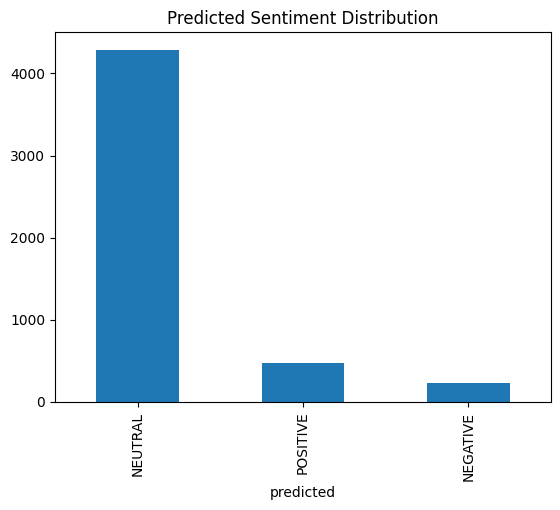

In [ ]:
import matplotlib.pyplot as plt

df['predicted'].value_counts().plot(kind='bar')
plt.title("Predicted Sentiment Distribution")
plt.show()

In [ ]:
import nltk
nltk.download('vader_lexicon')

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def vader_predict(text):
    score = sia.polarity_scores(text)['compound']
    if score >= 0.05:
        return "POSITIVE"
    elif score <= -0.05:
        return "NEGATIVE"
    else:
        return "NEUTRAL"

df['vader'] = df['text'].apply(vader_predict)

print("VADER Accuracy:", accuracy_score(df['actual'], df['vader']))

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


VADER Accuracy: 0.4802
